# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

# ---------- reproducibility / device ----------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [20]:
# ---------- hyperparams ----------
batch_size = 128
epochs = 10
lr = 1e-3
model_save_path = Path("mlp_mnist.pth")

# ---------- transforms & dataloaders ----------
transform = transforms.Compose([
    transforms.ToTensor(),                      # [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_ds   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train size: {len(train_ds)}  Val size: {len(val_ds)}  Batch size: {batch_size}")

Train size: 60000  Val size: 10000  Batch size: 64


In [21]:
# ---------------- MLP model ----------------
class MLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dims=[512, 256], num_classes=10, dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for i, h in enumerate(hidden_dims):
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
        # encoder: everything up to the final Linear (i.e., last hidden representation)
        # Build encoder from the same hidden dims (dropout + relu included)
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.ReLU(inplace=True))
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

# ---------------- helpers ----------------
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += float(loss.item()) * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

def extract_features(model, dataloader, device, max_batches=None):
    model.eval()
    feats = []
    labels = []
    with torch.no_grad():
        for i, (xb, yb) in enumerate(dataloader):
            xb = xb.to(device)
            f = model.encode(xb)
            feats.append(f.cpu())
            labels.append(yb)
            if (max_batches is not None) and (i+1 >= max_batches):
                break
    feats = torch.cat(feats, dim=0)
    labels = torch.cat(labels, dim=0)
    return feats, labels

In [22]:
# ---------------- instantiate ----------------
model = MLP(input_dim=28*28, hidden_dims=[512, 256], num_classes=10, dropout=0.2).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()


In [23]:
# ---------------- training loop ----------------
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
start_time = datetime.now()
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch,
                    "history": history}, model_save_path)

    print(f"Epoch {epoch:02d}/{epochs}  "
          f"Train loss: {train_loss:.4f}, acc: {train_acc*100:5.2f}%  "
          f"Val loss: {val_loss:.4f}, acc: {val_acc*100:5.2f}%")

end_time = datetime.now()
print("Training finished — elapsed:", (end_time - start_time))
print(f"Best val accuracy: {best_val_acc*100:.2f}%  (model saved to {model_save_path})")


Epoch 01/20  Train loss: 0.5140, acc: 86.00%  Val loss: 0.2788, acc: 92.98%
Epoch 02/20  Train loss: 0.4165, acc: 89.45%  Val loss: 0.2981, acc: 92.72%
Epoch 03/20  Train loss: 0.4091, acc: 89.86%  Val loss: 0.2342, acc: 93.62%
Epoch 04/20  Train loss: 0.3746, acc: 90.65%  Val loss: 0.2534, acc: 92.99%
Epoch 05/20  Train loss: 0.3674, acc: 91.02%  Val loss: 0.2534, acc: 93.98%
Epoch 06/20  Train loss: 0.3843, acc: 90.71%  Val loss: 0.2605, acc: 94.39%
Epoch 07/20  Train loss: 0.3578, acc: 91.32%  Val loss: 0.2128, acc: 94.95%
Epoch 08/20  Train loss: 0.3567, acc: 91.09%  Val loss: 0.2656, acc: 94.38%
Epoch 09/20  Train loss: 0.3663, acc: 91.18%  Val loss: 0.2461, acc: 93.79%
Epoch 10/20  Train loss: 0.3342, acc: 91.63%  Val loss: 0.2224, acc: 95.17%
Epoch 11/20  Train loss: 0.3465, acc: 91.69%  Val loss: 0.2704, acc: 94.14%
Epoch 12/20  Train loss: 0.3434, acc: 91.75%  Val loss: 0.2690, acc: 93.84%
Epoch 13/20  Train loss: 0.3534, acc: 91.66%  Val loss: 0.2596, acc: 93.33%
Epoch 14/20 

Validation features shape: torch.Size([10000, 256])
Validation labels shape:   torch.Size([10000])


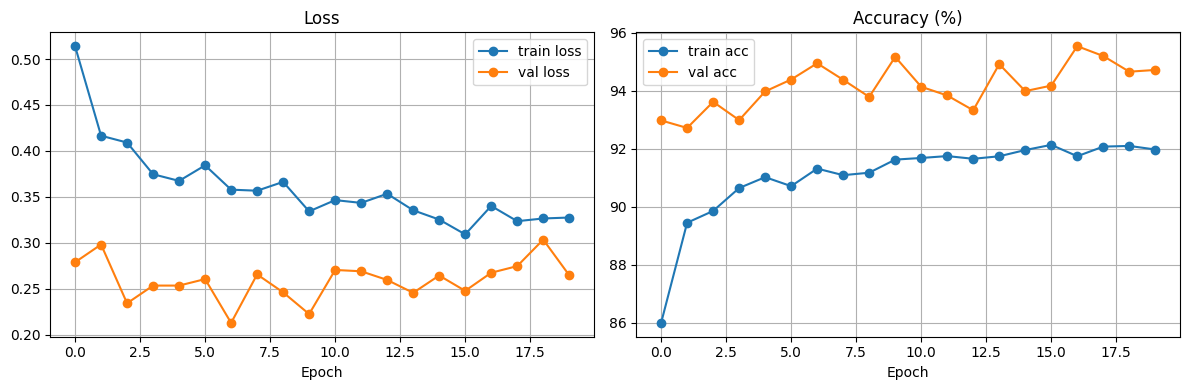

Saved: mlp_mnist.pth, mlp_history.json


In [24]:
# ---------------- feature extraction example ----------------
# Extract features for the entire validation set (careful: fits in RAM for MNIST)
val_feats, val_labels = extract_features(model, val_loader, device, max_batches=None)
print("Validation features shape:", val_feats.shape)  # (N, feature_dim)
print("Validation labels shape:  ", val_labels.shape)

# ---------------- plotting: loss & accuracy curves ----------------
plt.figure(figsize=(12,4))

# loss
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train loss", marker='o')
plt.plot(history["val_loss"],   label="val loss",   marker='o')
plt.title("Loss")
plt.xlabel("Epoch")
plt.grid(True)
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot([a*100 for a in history["train_acc"]], label="train acc", marker='o')
plt.plot([a*100 for a in history["val_acc"]],   label="val acc",   marker='o')
plt.title("Accuracy (%)")
plt.xlabel("Epoch")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ---------------- optional: save history to disk for later cells ----------------
import json
with open("mlp_history.json", "w") as f:
    json.dump({
        "train_loss": history["train_loss"],
        "val_loss": history["val_loss"],
        "train_acc": history["train_acc"],
        "val_acc": history["val_acc"]
    }, f)

print("Saved: mlp_mnist.pth, mlp_history.json")